# K-means Klaszterezés - Bank Marketing Dataset
## Age és Balance alapján

### Célkitűzések:
- K-means klaszterezés különböző klaszterszámokkal (k=2-8)
- Csak 2 változó: **age** (életkor) és **balance** (egyenleg)
- Elbow módszer és Silhouette analízis
- Validációs metrikák: Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index
- Klaszter profilozás és kategórikus változók elemzése
- Centroidok exportálása

## 1. Könyvtárak importálása

In [1]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_samples

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Könyvtárak sikeresen betöltve!")

✓ Könyvtárak sikeresen betöltve!


## 2. Adatok betöltése

In [2]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor:")
print(df.head())
print("\nAdattípusok:")
print(df.dtypes)
print("\nStatisztikák:")
print(df[['age', 'balance']].describe())

Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor:
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Adattípusok:
age           int64
job          object
marit

## 3. Feature Selection és Standardizálás

In [3]:
# Kiválasztott változók: AGE és BALANCE
features = ['age', 'balance']

# Feature mátrix előkészítése
X = df[features].copy()

print("="*70)
print("KIVÁLASZTOTT VÁLTOZÓK A KLASZTEREZÉSHEZ")
print("="*70)
print(f"Változók: {features}")
print(f"\nMinta méret: {len(X):,} rekord")
print("\nStatisztikák standardizálás előtt:")
print(X.describe())

# Standardizálás - KRITIKUS a K-means számára!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n" + "="*70)
print("✓ Adatok standardizálva (átlag=0, szórás=1)!")
print("="*70)
print(f"Standardizált adatok alakja: {X_scaled.shape}")
print(f"\nStandardizált adatok átlaga: {X_scaled.mean(axis=0)}")
print(f"Standardizált adatok szórása: {X_scaled.std(axis=0)}")

KIVÁLASZTOTT VÁLTOZÓK A KLASZTEREZÉSHEZ
Változók: ['age', 'balance']

Minta méret: 45,211 rekord

Statisztikák standardizálás előtt:
                age        balance
count  45211.000000   45211.000000
mean      40.936210    1362.272058
std       10.618762    3044.765829
min       18.000000   -8019.000000
25%       33.000000      72.000000
50%       39.000000     448.000000
75%       48.000000    1428.000000
max       95.000000  102127.000000

✓ Adatok standardizálva (átlag=0, szórás=1)!
Standardizált adatok alakja: (45211, 2)

Standardizált adatok átlaga: [2.1122502e-16 1.7602085e-17]
Standardizált adatok szórása: [1. 1.]


## 4. K-means Klaszterezés - Optimális K meghatározása
### 4.1 Metrikák számítása k=2-től k=8-ig

In [4]:
# Eredmények tárolása
k_range = range(2, 9)  # k=2-től k=8-ig
inertias = []
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []
models = {}

print("="*70)
print("K-MEANS KLASZTEREZÉS - k=2-től k=8-ig")
print("Paraméterek: random_state=42, n_init=50")
print("="*70)

for k in k_range:
    # K-means modell létrehozása
    # n_init=50 - több inicializálás a lokális optimumok elkerülésére
    # random_state=42 - reprodukálhatóság
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=300)
    labels = kmeans.fit_predict(X_scaled)
    
    # Modell mentése későbbi használatra
    models[k] = kmeans
    
    # Metrikák számítása
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))
    
    print(f"\nk={k}:")
    print(f"  Inertia (WCSS):        {kmeans.inertia_:>12,.2f}")
    print(f"  Silhouette Score:      {silhouette_scores[-1]:>12.4f}")
    print(f"  Davies-Bouldin Index:  {davies_bouldin_scores[-1]:>12.4f}")
    print(f"  Calinski-Harabasz:     {calinski_harabasz_scores[-1]:>12.2f}")

print("\n" + "="*70)
print("✓ Klaszterezések sikeresen végrehajtva!")
print("="*70)

K-MEANS KLASZTEREZÉS - k=2-től k=8-ig
Paraméterek: random_state=42, n_init=50

k=2:
  Inertia (WCSS):           58,332.65
  Silhouette Score:            0.4798
  Davies-Bouldin Index:        0.9195
  Calinski-Harabasz:         24869.95

k=3:
  Inertia (WCSS):           36,229.67
  Silhouette Score:            0.5096
  Davies-Bouldin Index:        0.7049
  Calinski-Harabasz:         33811.06

k=4:
  Inertia (WCSS):           28,026.25
  Silhouette Score:            0.5225
  Davies-Bouldin Index:        0.7113
  Calinski-Harabasz:         33548.70

k=5:
  Inertia (WCSS):           22,123.73
  Silhouette Score:            0.4299
  Davies-Bouldin Index:        0.7319
  Calinski-Harabasz:         34888.92

k=6:
  Inertia (WCSS):           18,451.26
  Silhouette Score:            0.4372
  Davies-Bouldin Index:        0.7207
  Calinski-Harabasz:         35265.24

k=7:
  Inertia (WCSS):           16,077.59
  Silhouette Score:            0.3738
  Davies-Bouldin Index:        0.8081
  Calinski-H

In [5]:
# Eredmények DataFrame-be szervezése
results_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': davies_bouldin_scores,
    'Calinski-Harabasz Index': calinski_harabasz_scores
})

print("\n" + "="*90)
print("ÖSSZESÍTETT VALIDÁCIÓS EREDMÉNYEK")
print("="*90)
print(results_df.to_string(index=False))

# Optimális k értékek az egyes metrikák szerint
print("\n" + "="*90)
print("OPTIMÁLIS K ÉRTÉKEK METRIKÁK SZERINT")
print("="*90)
print(f"Legmagasabb Silhouette Score:      k={results_df.loc[results_df['Silhouette Score'].idxmax(), 'k']:.0f} "
      f"(érték: {results_df['Silhouette Score'].max():.4f})")
print(f"Legalacsonyabb Davies-Bouldin:     k={results_df.loc[results_df['Davies-Bouldin Index'].idxmin(), 'k']:.0f} "
      f"(érték: {results_df['Davies-Bouldin Index'].min():.4f})")
print(f"Legmagasabb Calinski-Harabasz:     k={results_df.loc[results_df['Calinski-Harabasz Index'].idxmax(), 'k']:.0f} "
      f"(érték: {results_df['Calinski-Harabasz Index'].max():.2f})")
print("="*90)


ÖSSZESÍTETT VALIDÁCIÓS EREDMÉNYEK
 k      Inertia  Silhouette Score  Davies-Bouldin Index  Calinski-Harabasz Index
 2 58332.653876          0.479787              0.919472             24869.953808
 3 36229.668204          0.509600              0.704942             33811.059517
 4 28026.253824          0.522535              0.711327             33548.704180
 5 22123.733459          0.429934              0.731861             34888.916474
 6 18451.259060          0.437210              0.720698             35265.244737
 7 16077.587936          0.373804              0.808100             34838.049378
 8 14012.649331          0.384491              0.811447             35213.408973

OPTIMÁLIS K ÉRTÉKEK METRIKÁK SZERINT
Legmagasabb Silhouette Score:      k=4 (érték: 0.5225)
Legalacsonyabb Davies-Bouldin:     k=3 (érték: 0.7049)
Legmagasabb Calinski-Harabasz:     k=6 (érték: 35265.24)


### 4.2 Elbow módszer vizualizációja

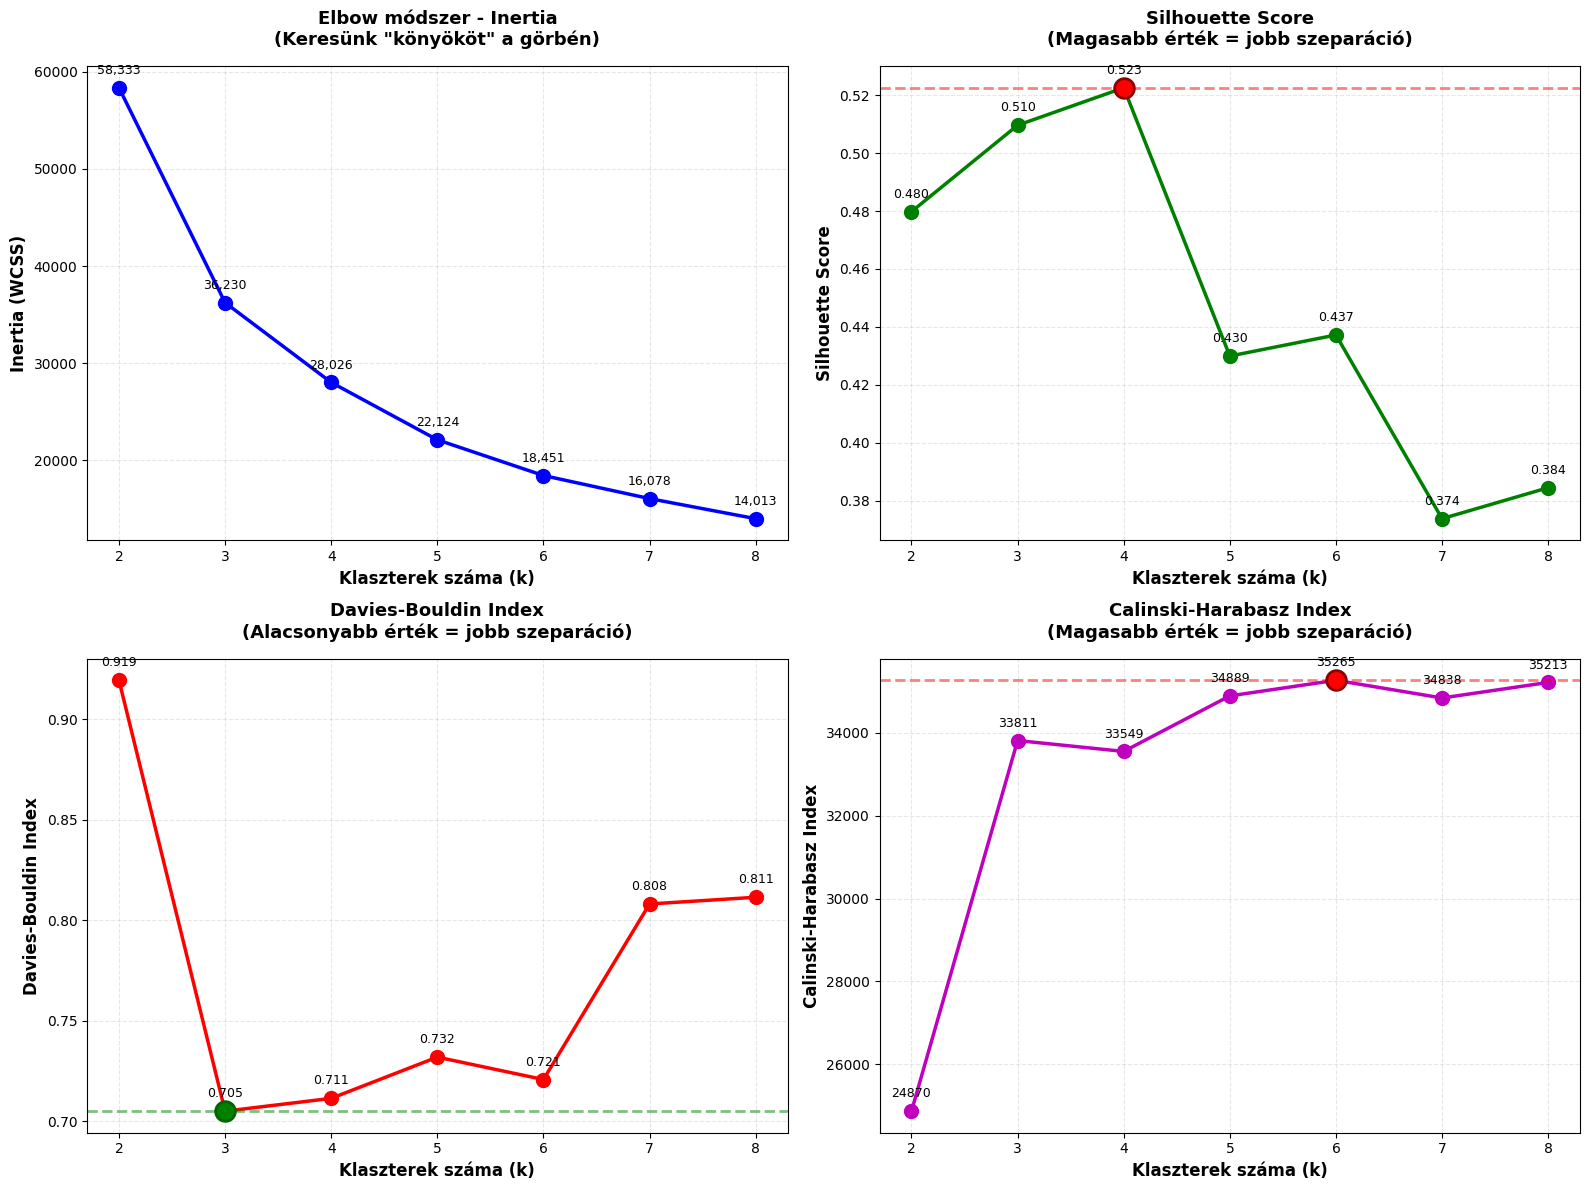

✓ Elbow diagram mentve: ábrák/kmeans_elbow_method.png


In [6]:
# Elbow módszer - 4 metrika vizualizációja
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Inertia (Within-Cluster Sum of Squares) - ELBOW MÓDSZER
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2.5, markersize=10)
axes[0, 0].set_xlabel('Klaszterek száma (k)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Inertia (WCSS)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Elbow módszer - Inertia\n(Keresünk "könyököt" a görbén)', 
                     fontsize=13, fontweight='bold', pad=15)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
axes[0, 0].set_xticks(k_range)
for i, (k, inertia) in enumerate(zip(k_range, inertias)):
    axes[0, 0].annotate(f'{inertia:,.0f}', (k, inertia), 
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# 2. Silhouette Score (magasabb = jobb)
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2.5, markersize=10)
axes[0, 1].set_xlabel('Klaszterek száma (k)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Silhouette Score\n(Magasabb érték = jobb szeparáció)', 
                     fontsize=13, fontweight='bold', pad=15)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')
axes[0, 1].set_xticks(k_range)
best_silhouette_k = results_df.loc[results_df['Silhouette Score'].idxmax(), 'k']
best_silhouette_val = results_df['Silhouette Score'].max()
axes[0, 1].axhline(y=best_silhouette_val, color='r', linestyle='--', alpha=0.5, linewidth=2)
axes[0, 1].scatter([best_silhouette_k], [best_silhouette_val], color='red', s=200, zorder=5, 
                  edgecolors='darkred', linewidths=2)
for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    axes[0, 1].annotate(f'{score:.3f}', (k, score), 
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# 3. Davies-Bouldin Index (alacsonyabb = jobb)
axes[1, 0].plot(k_range, davies_bouldin_scores, 'ro-', linewidth=2.5, markersize=10)
axes[1, 0].set_xlabel('Klaszterek száma (k)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Davies-Bouldin Index\n(Alacsonyabb érték = jobb szeparáció)', 
                     fontsize=13, fontweight='bold', pad=15)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
axes[1, 0].set_xticks(k_range)
best_db_k = results_df.loc[results_df['Davies-Bouldin Index'].idxmin(), 'k']
best_db_val = results_df['Davies-Bouldin Index'].min()
axes[1, 0].axhline(y=best_db_val, color='g', linestyle='--', alpha=0.5, linewidth=2)
axes[1, 0].scatter([best_db_k], [best_db_val], color='green', s=200, zorder=5, 
                  edgecolors='darkgreen', linewidths=2)
for i, (k, score) in enumerate(zip(k_range, davies_bouldin_scores)):
    axes[1, 0].annotate(f'{score:.3f}', (k, score), 
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

# 4. Calinski-Harabasz Index (magasabb = jobb)
axes[1, 1].plot(k_range, calinski_harabasz_scores, 'mo-', linewidth=2.5, markersize=10)
axes[1, 1].set_xlabel('Klaszterek száma (k)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Calinski-Harabasz Index', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Calinski-Harabasz Index\n(Magasabb érték = jobb szeparáció)', 
                     fontsize=13, fontweight='bold', pad=15)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')
axes[1, 1].set_xticks(k_range)
best_ch_k = results_df.loc[results_df['Calinski-Harabasz Index'].idxmax(), 'k']
best_ch_val = results_df['Calinski-Harabasz Index'].max()
axes[1, 1].axhline(y=best_ch_val, color='r', linestyle='--', alpha=0.5, linewidth=2)
axes[1, 1].scatter([best_ch_k], [best_ch_val], color='red', s=200, zorder=5, 
                  edgecolors='darkred', linewidths=2)
for i, (k, score) in enumerate(zip(k_range, calinski_harabasz_scores)):
    axes[1, 1].annotate(f'{score:.0f}', (k, score), 
                       textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('ábrák/kmeans_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Elbow diagram mentve: ábrák/kmeans_elbow_method.png")

### 4.3 Silhouette Plot - Részletes analízis

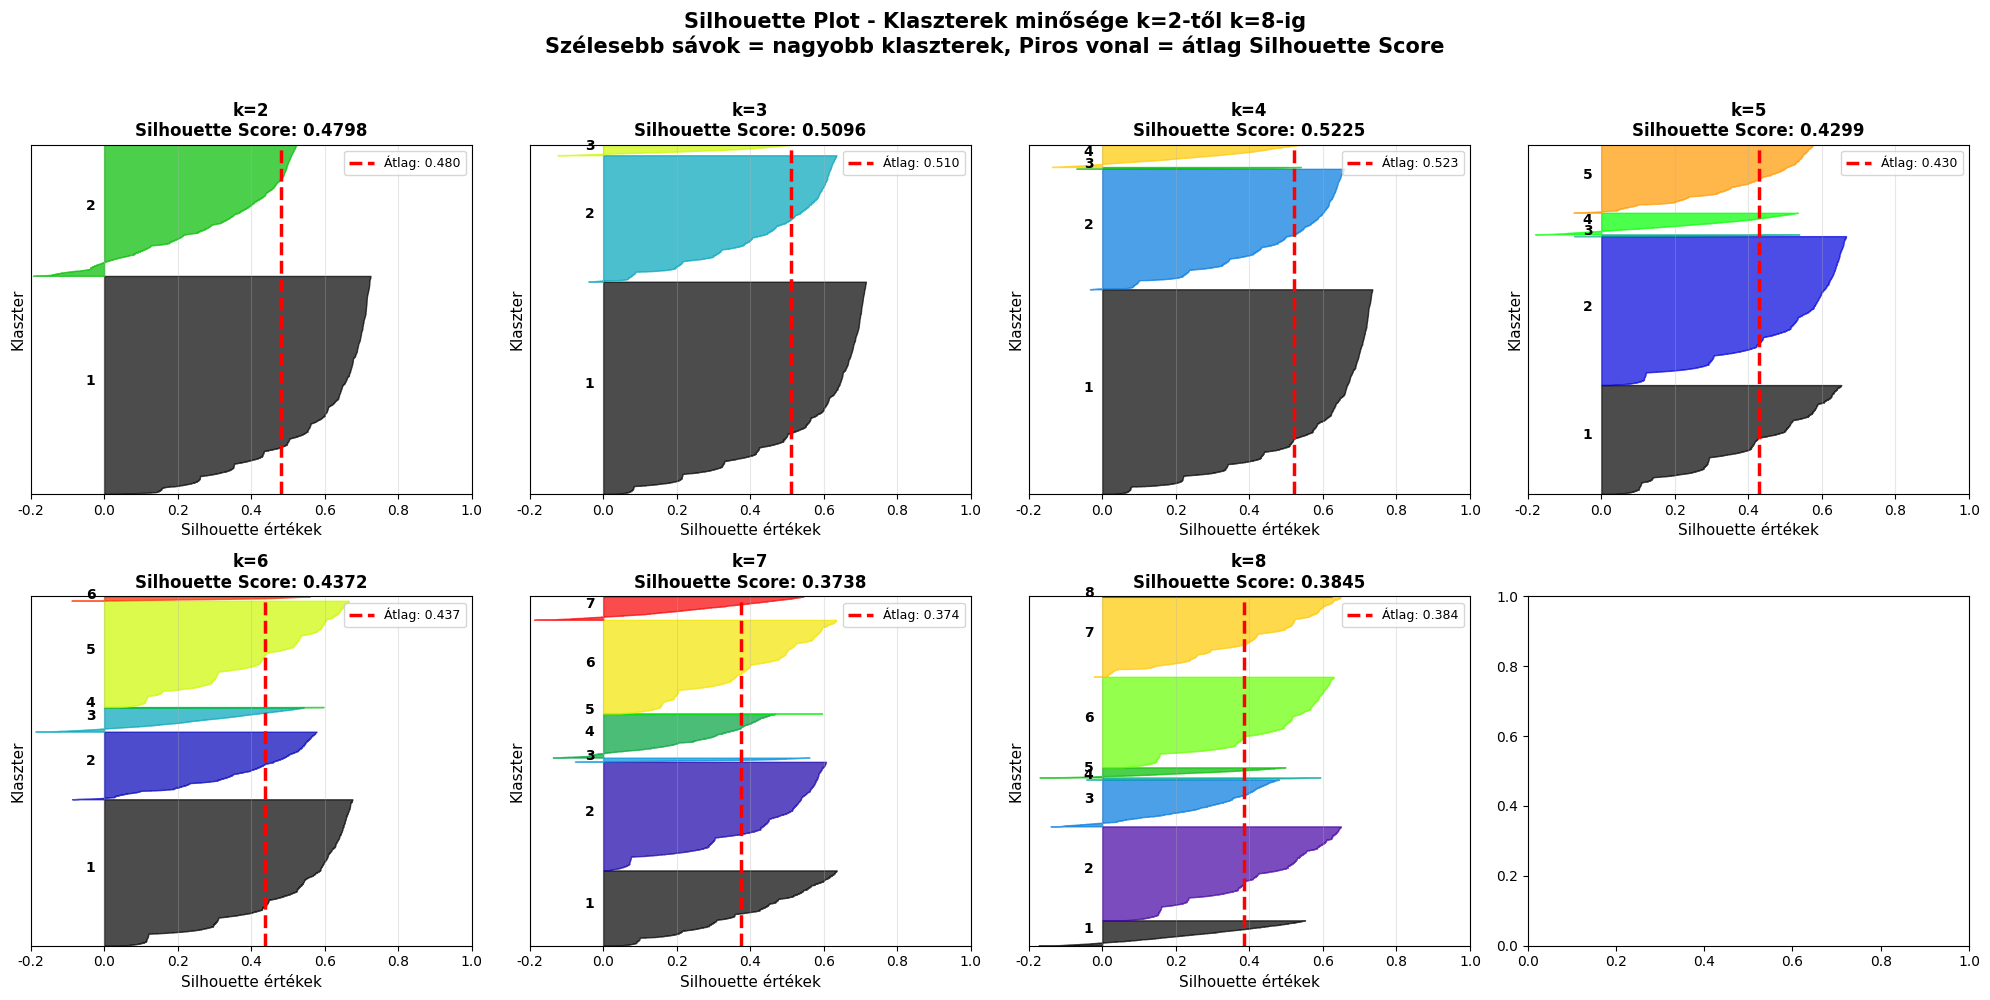

✓ Silhouette plotok mentve: ábrák/kmeans_silhouette_plots.png


In [7]:
# Silhouette plot minden k értékhez
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, k in enumerate(k_range):
    ax = axes[idx]
    
    # Klaszter címkék és silhouette értékek
    kmeans = models[k]
    cluster_labels = kmeans.labels_
    silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
    
    y_lower = 10
    for i in range(k):
        # i-edik klaszter silhouette értékei
        cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
        cluster_silhouette_vals.sort()
        
        size_cluster_i = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = plt.cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                        0, cluster_silhouette_vals,
                        facecolor=color, edgecolor=color, alpha=0.7)
        
        # Klaszter szám jelölése
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1), 
               fontweight='bold', fontsize=10)
        y_lower = y_upper + 10
    
    ax.set_title(f'k={k}\nSilhouette Score: {silhouette_scores[idx]:.4f}', 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Silhouette értékek', fontsize=11)
    ax.set_ylabel('Klaszter', fontsize=11)
    
    # Átlag jelölése
    ax.axvline(x=silhouette_scores[idx], color="red", linestyle="--", linewidth=2.5, 
              label=f'Átlag: {silhouette_scores[idx]:.3f}')
    ax.set_xlim([-0.2, 1])
    ax.set_ylim([0, len(X_scaled) + (k + 1) * 10])
    ax.set_yticks([])
    ax.grid(True, alpha=0.3, axis='x')
    ax.legend(loc='upper right', fontsize=9)

# Főcím hozzáadása
fig.suptitle('Silhouette Plot - Klaszterek minősége k=2-től k=8-ig\n' + 
             'Szélesebb sávok = nagyobb klaszterek, Piros vonal = átlag Silhouette Score', 
             fontsize=15, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('ábrák/kmeans_silhouette_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Silhouette plotok mentve: ábrák/kmeans_silhouette_plots.png")

## 5. Optimális Modell Kiválasztása és Elemzése

In [8]:
# Optimális k kiválasztása (a Silhouette Score alapján)
optimal_k = results_df.loc[results_df['Silhouette Score'].idxmax(), 'k'].astype(int)

print("\n" + "="*90)
print(f"OPTIMÁLIS KLASZTERSZÁM: k={optimal_k}")
print("="*90)
print(f"\nKiválasztás alapja: Legmagasabb Silhouette Score")
print(f"\nOptimális modell metrikái:")
optimal_row = results_df[results_df['k'] == optimal_k].iloc[0]
print(f"  Silhouette Score:       {optimal_row['Silhouette Score']:>10.4f}")
print(f"  Davies-Bouldin Index:   {optimal_row['Davies-Bouldin Index']:>10.4f}")
print(f"  Calinski-Harabasz:      {optimal_row['Calinski-Harabasz Index']:>10.2f}")
print(f"  Inertia (WCSS):         {optimal_row['Inertia']:>10,.2f}")

# Optimális modell
optimal_model = models[optimal_k]
optimal_labels = optimal_model.labels_

# Címkék hozzáadása az adathalmazhoz
df['cluster'] = optimal_labels

print(f"\n✓ Klaszter címkék hozzáadva az adathalmazhoz!")
print(f"\nKlaszterek eloszlása:")
print("="*90)
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    percentage = count / len(df) * 100
    print(f"  Klaszter {cluster_id}: {count:>6,} ügyfél ({percentage:>5.2f}%)")
print("="*90)


OPTIMÁLIS KLASZTERSZÁM: k=4

Kiválasztás alapja: Legmagasabb Silhouette Score

Optimális modell metrikái:
  Silhouette Score:           0.5225
  Davies-Bouldin Index:       0.7113
  Calinski-Harabasz:        33548.70
  Inertia (WCSS):          28,026.25

✓ Klaszter címkék hozzáadva az adathalmazhoz!

Klaszterek eloszlása:
  Klaszter 0: 26,509 ügyfél (58.63%)
  Klaszter 1: 15,599 ügyfél (34.50%)
  Klaszter 2:    223 ügyfél ( 0.49%)
  Klaszter 3:  2,880 ügyfél ( 6.37%)


### 5.1 Centroidok exportálása

In [9]:
# Centroidok visszaalakítása az eredeti skálára
centroids_scaled = optimal_model.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)

# DataFrame létrehozása
centroids_df = pd.DataFrame(
    centroids_original,
    columns=features,
    index=[f'Cluster_{i}' for i in range(optimal_k)]
)

# Klaszter méret hozzáadása
cluster_sizes = df['cluster'].value_counts().sort_index()
centroids_df['cluster_size'] = cluster_sizes.values
centroids_df['cluster_percentage'] = (centroids_df['cluster_size'] / len(df) * 100).round(2)

# Átnevezés olvashatóbbá
centroids_df = centroids_df.rename(columns={
    'age': 'Átlag életkor (év)',
    'balance': 'Átlag egyenleg (€)',
    'cluster_size': 'Ügyfelek száma',
    'cluster_percentage': 'Arány (%)'
})

print("\n" + "="*90)
print("KLASZTER CENTROIDOK (eredeti skálán)")
print("="*90)
print(centroids_df.to_string())
print("="*90)

# Exportálás CSV-be
centroids_df.to_csv('ábrák/kmeans_centroids.csv', encoding='utf-8-sig')
print("\n✓ Centroidok exportálva: ábrák/kmeans_centroids.csv")


KLASZTER CENTROIDOK (eredeti skálán)
           Átlag életkor (év)  Átlag egyenleg (€)  Ügyfelek száma  Arány (%)
Cluster_0           33.996455          682.076450           26509      58.63
Cluster_1           52.436418          933.833034           15599      34.50
Cluster_2           46.461883        28740.058296             223       0.49
Cluster_3           42.099930         7843.457869            2880       6.37

✓ Centroidok exportálva: ábrák/kmeans_centroids.csv


## 6. Klaszter Profilozás
### 6.1 Numerikus változók szerinti profilozás

In [10]:
# Numerikus változók listája (minden numerikus változó)
numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

# Klaszterek profilozása - átlag és szórás
print("\n" + "="*100)
print("KLASZTER PROFILOK - NUMERIKUS VÁLTOZÓK")
print("="*100)

cluster_profile_numeric = df.groupby('cluster')[numeric_cols].agg(['mean', 'std']).round(2)
print(cluster_profile_numeric)

# Exportálás
cluster_profile_numeric.to_csv('ábrák/kmeans_cluster_profile_numeric.csv', encoding='utf-8-sig')
print("\n✓ Numerikus profilok exportálva: ábrák/kmeans_cluster_profile_numeric.csv")


KLASZTER PROFILOK - NUMERIKUS VÁLTOZÓK
           age          balance              day       duration          \
          mean    std      mean       std   mean   std     mean     std   
cluster                                                                   
0        33.99   5.09    681.73    974.29  15.77  8.35   260.18  255.58   
1        52.43   6.97    931.97   1227.96  15.79  8.35   252.32  257.07   
2        46.46  12.27  28740.06  13303.79  15.78  8.09   256.06  255.57   
3        42.14   9.68   7837.10   3123.95  16.18  7.87   271.36  276.69   

        campaign        pdays         previous        
            mean   std   mean     std     mean   std  
cluster                                               
0           2.76  3.20  43.19  105.06     0.59  2.55  
1           2.79  2.91  35.21   92.56     0.54  1.82  
2           2.69  3.18  32.74   93.28     0.57  1.98  
3           2.69  3.11  40.23   92.18     0.68  2.24  

✓ Numerikus profilok exportálva: ábrák/kmeans_cl

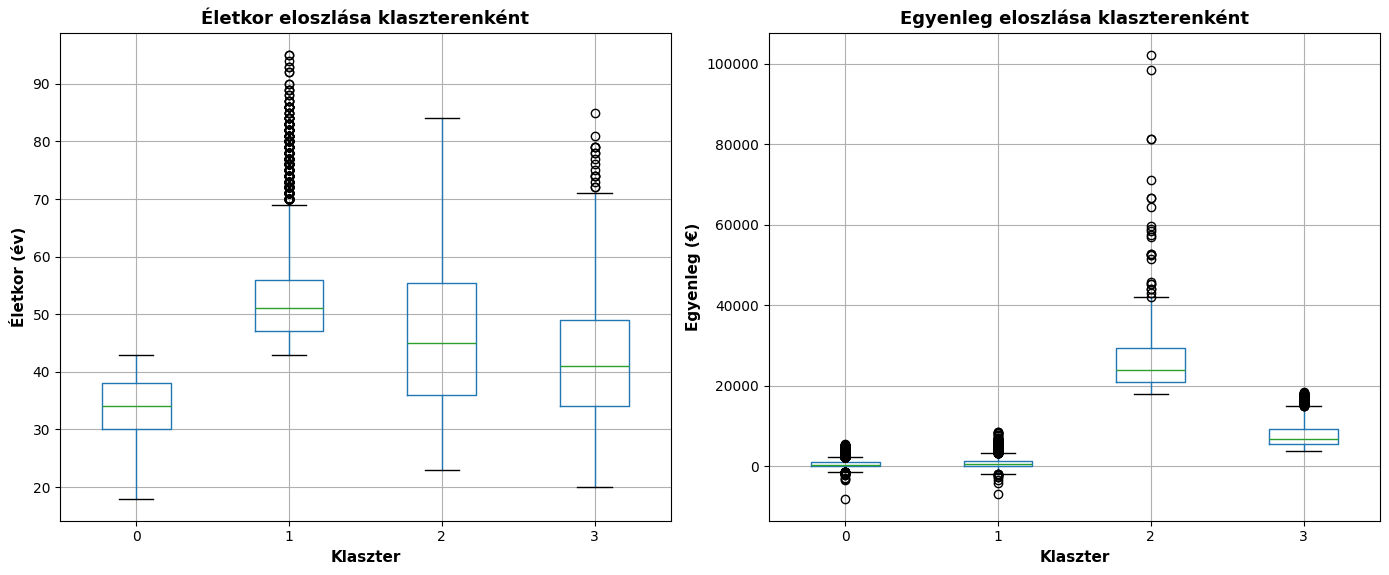

✓ Box plotok mentve: ábrák/kmeans_cluster_boxplots.png


In [11]:
# Vizualizáció - Box plotok klaszterenként a 2 klaszterezési változóra
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Age boxplot
df.boxplot(column='age', by='cluster', ax=axes[0])
axes[0].set_title('Életkor eloszlása klaszterenként', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Klaszter', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Életkor (év)', fontsize=11, fontweight='bold')
axes[0].get_figure().suptitle('')  # Pandas default cím eltávolítása

# Balance boxplot
df.boxplot(column='balance', by='cluster', ax=axes[1])
axes[1].set_title('Egyenleg eloszlása klaszterenként', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Klaszter', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Egyenleg (€)', fontsize=11, fontweight='bold')
axes[1].get_figure().suptitle('')  # Pandas default cím eltávolítása

plt.tight_layout()
plt.savefig('ábrák/kmeans_cluster_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Box plotok mentve: ábrák/kmeans_cluster_boxplots.png")

### 6.2 Kategorikus változók szerinti profilozás

In [12]:
# Kategorikus változók listája
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 
                   'contact', 'month', 'poutcome', 'y']

print("\n" + "="*100)
print("KATEGORIKUS VÁLTOZÓK ELEMZÉSE KLASZTERENKÉNT")
print("="*100)

# Minden kategorikus változóra
categorical_profiles = {}

for col in categorical_cols:
    # Kereszttábla készítése
    crosstab = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    categorical_profiles[col] = crosstab
    
    print(f"\n{col.upper()} - Százalékos eloszlás klaszterenként:")
    print("-" * 80)
    print(crosstab.round(2))
    
    # Exportálás
    crosstab.to_csv(f'ábrák/kmeans_cluster_{col}.csv', encoding='utf-8-sig')

print("\n" + "="*100)
print("✓ Kategorikus változók profiljai exportálva: ábrák/kmeans_cluster_*.csv")
print("="*100)


KATEGORIKUS VÁLTOZÓK ELEMZÉSE KLASZTERENKÉNT

JOB - Százalékos eloszlás klaszterenként:
--------------------------------------------------------------------------------
job      admin.  blue-collar  entrepreneur  housemaid  management  retired  \
cluster                                                                      
0         12.68        22.65          3.01       1.74       21.10     0.22   
1         10.03        20.67          3.69       4.48       18.76    13.26   
2          6.73         5.38          8.52       3.14       41.26    11.21   
3          8.02        17.05          3.30       2.57       29.41     3.89   

job      self-employed  services  student  technician  unemployed  unknown  
cluster                                                                     
0                 3.49     10.31     3.30       18.39        2.80     0.32  
1                 3.28      7.71     0.03       14.07        2.90     1.13  
2                 4.93      4.04     1.35        9.42

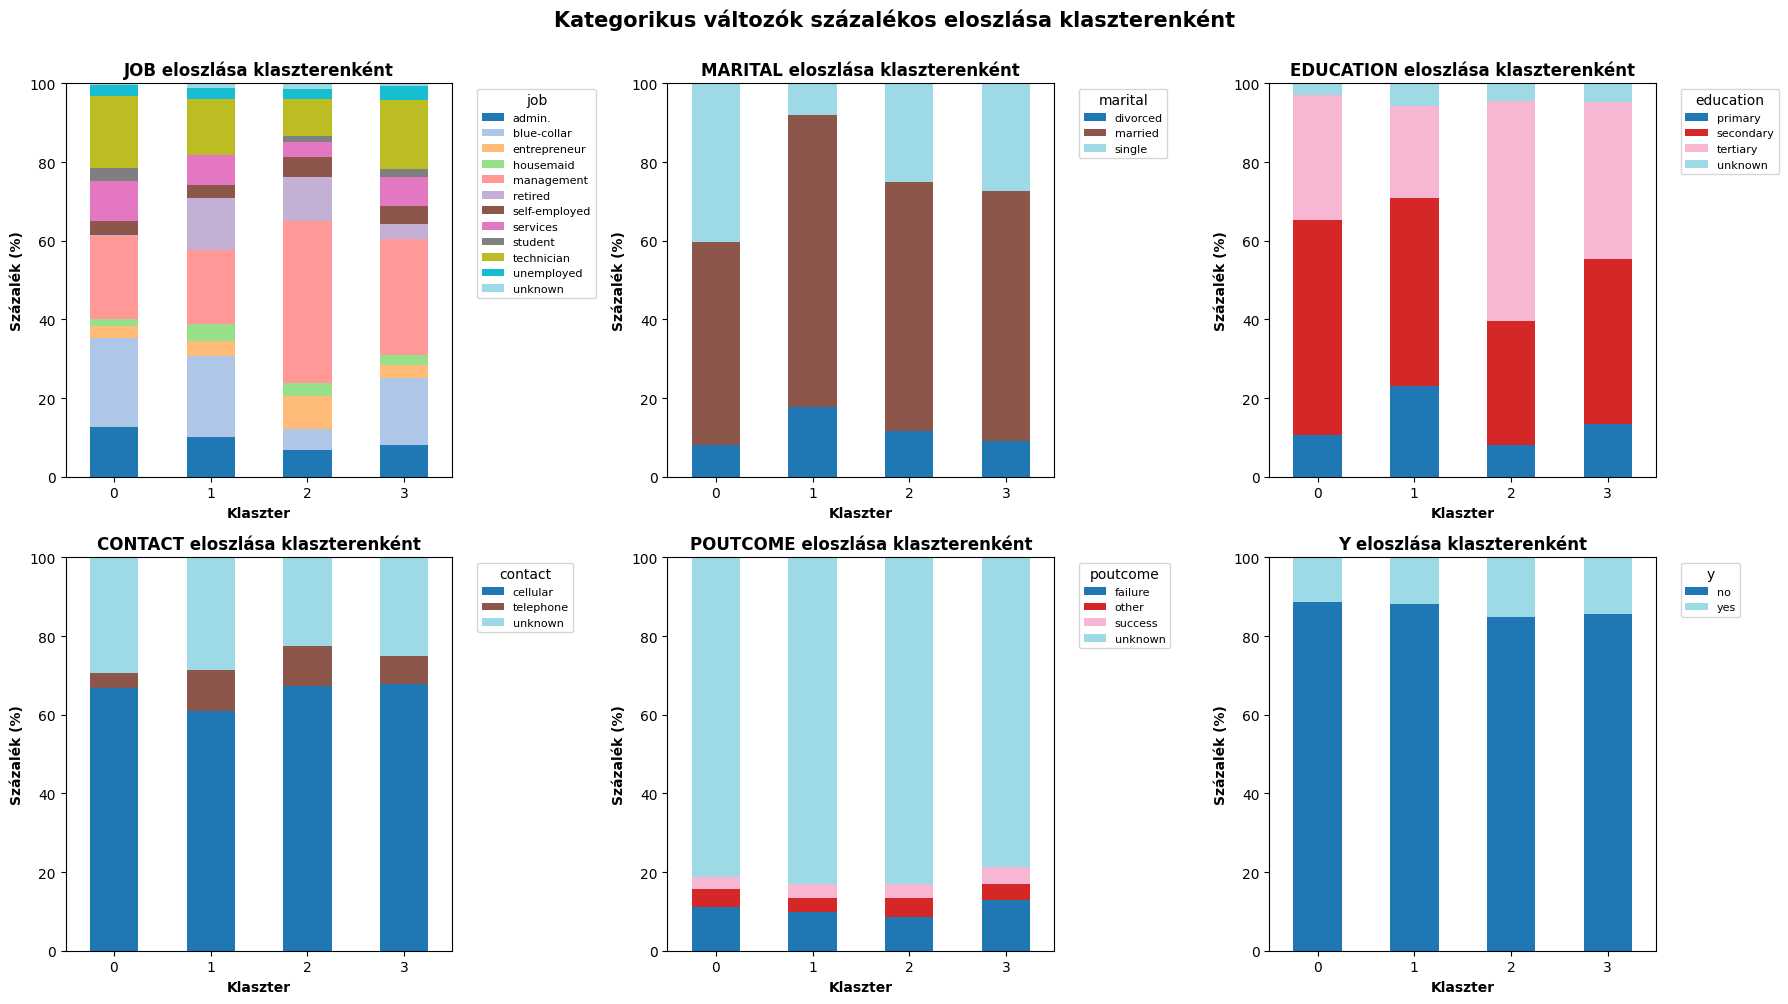

✓ Kategorikus eloszlások mentve: ábrák/kmeans_categorical_distributions.png


In [13]:
# Vizualizáció - Stacked bar chart a fontosabb kategorikus változókra
important_categorical = ['job', 'marital', 'education', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    ax = axes[idx]
    crosstab = pd.crosstab(df['cluster'], df[col], normalize='index') * 100
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    ax.set_title(f'{col.upper()} eloszlása klaszterenként', fontsize=12, fontweight='bold')
    ax.set_xlabel('Klaszter', fontsize=10, fontweight='bold')
    ax.set_ylabel('Százalék (%)', fontsize=10, fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim([0, 100])

plt.suptitle('Kategorikus változók százalékos eloszlása klaszterenként', 
            fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ábrák/kmeans_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Kategorikus eloszlások mentve: ábrák/kmeans_categorical_distributions.png")

### 6.3 Klaszter jellemzők részletes összefoglalása

In [14]:
# Átfogó profil minden klaszterhez
print("\n" + "="*100)
print("KLASZTER JELLEMZŐK RÉSZLETES ÖSSZEFOGLALÁSA")
print("="*100)

for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*100}")
    print(f"KLASZTER {cluster_id} - {len(cluster_data):,} ügyfél ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*100}")
    
    # Klaszterezési változók (age, balance)
    print("\n🎯 KLASZTEREZÉSI VÁLTOZÓK:")
    print(f"  Átlagos életkor:   {cluster_data['age'].mean():>8.1f} év (±{cluster_data['age'].std():.1f})")
    print(f"  Átlagos egyenleg:  {cluster_data['balance'].mean():>8,.0f} € (±{cluster_data['balance'].std():,.0f})")
    
    # További numerikus jellemzők
    print("\n📊 TOVÁBBI NUMERIKUS JELLEMZŐK:")
    print(f"  Átlagos hívás időtartam:  {cluster_data['duration'].mean():>6.0f} mp (±{cluster_data['duration'].std():.0f})")
    print(f"  Átlagos kampány kapcsolat: {cluster_data['campaign'].mean():>6.1f} (±{cluster_data['campaign'].std():.1f})")
    print(f"  Korábbi kampányok:        {cluster_data['previous'].mean():>6.2f} (±{cluster_data['previous'].std():.2f})")
    
    # Kategorikus jellemzők (top 3)
    print("\n👥 KATEGORIKUS JELLEMZŐK (Top értékek):")
    
    top_job = cluster_data['job'].value_counts().head(3)
    print(f"  Leggyakoribb foglalkozások:")
    for job, count in top_job.items():
        print(f"    - {job}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    print(f"\n  Családi állapot:")
    for marital, count in cluster_data['marital'].value_counts().items():
        print(f"    - {marital}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    top_edu = cluster_data['education'].value_counts().head(3)
    print(f"\n  Végzettség (top 3):")
    for edu, count in top_edu.items():
        print(f"    - {edu}: {count} ({count/len(cluster_data)*100:.1f}%)")
    
    # Konverziós arány (ha 'y' a célváltozó)
    conversion_rate = (cluster_data['y'] == 'yes').sum() / len(cluster_data) * 100
    print(f"\n  💰 Konverziós arány (deposit = yes): {conversion_rate:.2f}%")
    print(f"     ({(cluster_data['y'] == 'yes').sum()} / {len(cluster_data)} ügyfél)")

print("\n" + "="*100)


KLASZTER JELLEMZŐK RÉSZLETES ÖSSZEFOGLALÁSA

KLASZTER 0 - 26,509 ügyfél (58.6%)

🎯 KLASZTEREZÉSI VÁLTOZÓK:
  Átlagos életkor:       34.0 év (±5.1)
  Átlagos egyenleg:       682 € (±974)

📊 TOVÁBBI NUMERIKUS JELLEMZŐK:
  Átlagos hívás időtartam:     260 mp (±256)
  Átlagos kampány kapcsolat:    2.8 (±3.2)
  Korábbi kampányok:          0.59 (±2.55)

👥 KATEGORIKUS JELLEMZŐK (Top értékek):
  Leggyakoribb foglalkozások:
    - blue-collar: 6004 (22.6%)
    - management: 5593 (21.1%)
    - technician: 4876 (18.4%)

  Családi állapot:
    - married: 13655 (51.5%)
    - single: 10685 (40.3%)
    - divorced: 2169 (8.2%)

  Végzettség (top 3):
    - secondary: 14491 (54.7%)
    - tertiary: 8369 (31.6%)
    - primary: 2841 (10.7%)

  💰 Konverziós arány (deposit = yes): 11.31%
     (2999 / 26509 ügyfél)

KLASZTER 1 - 15,599 ügyfél (34.5%)

🎯 KLASZTEREZÉSI VÁLTOZÓK:
  Átlagos életkor:       52.4 év (±7.0)
  Átlagos egyenleg:       932 € (±1,228)

📊 TOVÁBBI NUMERIKUS JELLEMZŐK:
  Átlagos hívás időta

## 7. Vizualizációk - 2D Scatter Plot

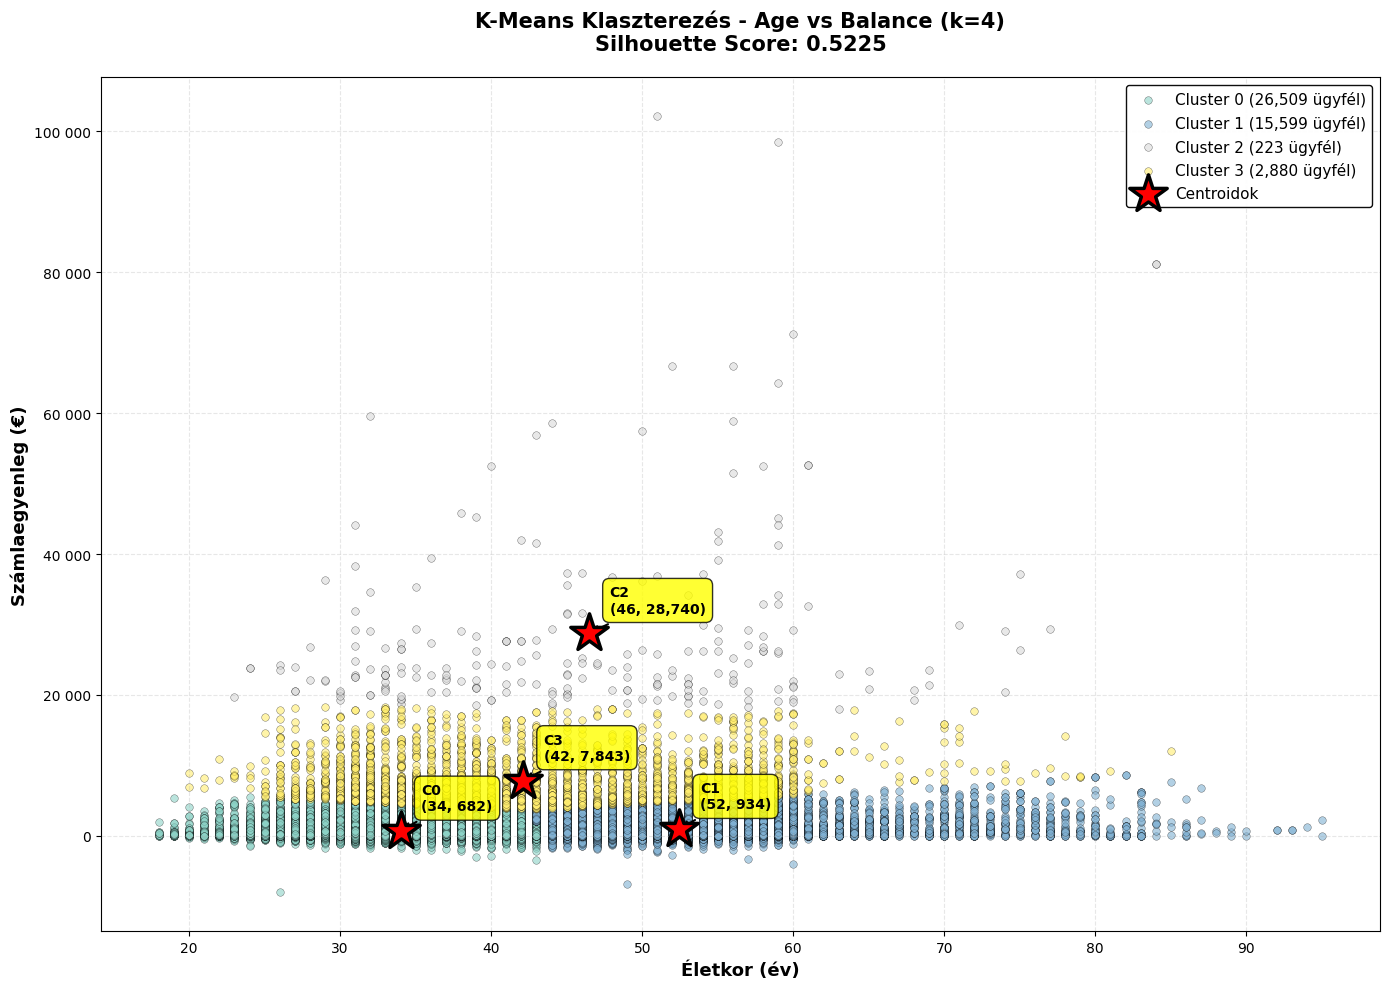

✓ 2D scatter plot mentve: ábrák/kmeans_2d_scatter.png


In [15]:
# 2D scatter plot - Age vs Balance (a 2 klaszterezési változó)
fig, ax = plt.subplots(figsize=(14, 10))

# Színek definiálása
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))

# Klaszterek ábrázolása
for cluster_id in range(optimal_k):
    cluster_data = df[df['cluster'] == cluster_id]
    ax.scatter(cluster_data['age'], cluster_data['balance'], 
              label=f'Cluster {cluster_id} ({len(cluster_data):,} ügyfél)', 
              alpha=0.6, s=30, c=[colors[cluster_id]], edgecolors='black', linewidths=0.3)

# Centroidok ábrázolása
ax.scatter(centroids_original[:, 0], centroids_original[:, 1], 
          marker='*', s=800, c='red', edgecolors='black', linewidths=2.5, 
          label='Centroidok', zorder=10)

# Centroid címkék
for i, (x, y) in enumerate(centroids_original):
    ax.annotate(f'C{i}\n({x:.0f}, {y:,.0f})', 
               (x, y), 
               xytext=(15, 15), 
               textcoords='offset points',
               fontsize=10,
               fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8, edgecolor='black'),
               arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', lw=1.5))

ax.set_xlabel('Életkor (év)', fontsize=13, fontweight='bold')
ax.set_ylabel('Számlaegyenleg (€)', fontsize=13, fontweight='bold')
ax.set_title(f'K-Means Klaszterezés - Age vs Balance (k={optimal_k})\n' + 
            f'Silhouette Score: {optimal_row["Silhouette Score"]:.4f}', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely formázása ezres elválasztóval
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('ábrák/kmeans_2d_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ 2D scatter plot mentve: ábrák/kmeans_2d_scatter.png")

## 8. Összefoglaló és következtetések

In [16]:
print("\n" + "="*100)
print("K-MEANS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. MÓDSZERTAN:")
print(f"   - Vizsgált klaszterszámok: k=2-től k=8-ig")
print(f"   - Inicializálások száma: n_init=50 (lokális optimumok elkerülésére)")
print(f"   - Random state: 42 (reprodukálhatóság)")
print(f"   - Használt változók: {', '.join(features)}")
print(f"   - Standardizálás: StandardScaler (átlag=0, szórás=1)")

print(f"\n2. OPTIMÁLIS MODELL:")
print(f"   - Optimális klaszterszám: k={optimal_k}")
print(f"   - Silhouette Score: {optimal_row['Silhouette Score']:.4f}")
print(f"   - Davies-Bouldin Index: {optimal_row['Davies-Bouldin Index']:.4f} (alacsonyabb = jobb)")
print(f"   - Calinski-Harabasz Index: {optimal_row['Calinski-Harabasz Index']:.2f} (magasabb = jobb)")
print(f"   - Inertia (WCSS): {optimal_row['Inertia']:,.2f}")

print(f"\n3. KLASZTEREK MÉRETE:")
for cluster_id in range(optimal_k):
    count = (df['cluster'] == cluster_id).sum()
    percentage = count / len(df) * 100
    avg_age = df[df['cluster'] == cluster_id]['age'].mean()
    avg_balance = df[df['cluster'] == cluster_id]['balance'].mean()
    print(f"   Klaszter {cluster_id}: {count:>6,} ügyfél ({percentage:>5.1f}%) - "
          f"Átlag kor: {avg_age:.0f} év, Átlag egyenleg: {avg_balance:,.0f} €")

print(f"\n4. EXPORTÁLT FÁJLOK:")
print(f"   CSV fájlok:")
print(f"   - ábrák/kmeans_centroids.csv - Klaszter centroidok")
print(f"   - ábrák/kmeans_cluster_profile_numeric.csv - Numerikus profilok")
print(f"   - ábrák/kmeans_cluster_*.csv - Kategorikus változók eloszlásai")
print(f"   \n   PNG ábrák:")
print(f"   - ábrák/kmeans_elbow_method.png - Elbow diagram (4 metrika)")
print(f"   - ábrák/kmeans_silhouette_plots.png - Silhouette plotok (k=2-8)")
print(f"   - ábrák/kmeans_cluster_boxplots.png - Box plotok")
print(f"   - ábrák/kmeans_categorical_distributions.png - Kategorikus eloszlások")
print(f"   - ábrák/kmeans_2d_scatter.png - 2D scatter plot")

print(f"\n5. KÖVETKEZTETÉSEK:")
print(f"   A k-means klaszterezés sikeresen azonosította a bank ügyfeleinek {optimal_k} jól")
print(f"   elkülöníthető szegmensét életkor és számlaegyenleg alapján.")
print(f"   ")
print(f"   A klaszterek jól szeparáltak (Silhouette Score: {optimal_row['Silhouette Score']:.4f}) és használhatók")
print(f"   célzott marketing kampányok tervezéséhez és ügyfélarányos szolgáltatások")
print(f"   kidolgozásához.")

print("\n" + "="*100)
print("✓ KLASZTEREZÉS SIKERESEN BEFEJEZVE!")
print("="*100)


K-MEANS KLASZTEREZÉS - VÉGSŐ ÖSSZEFOGLALÓ

1. MÓDSZERTAN:
   - Vizsgált klaszterszámok: k=2-től k=8-ig
   - Inicializálások száma: n_init=50 (lokális optimumok elkerülésére)
   - Random state: 42 (reprodukálhatóság)
   - Használt változók: age, balance
   - Standardizálás: StandardScaler (átlag=0, szórás=1)

2. OPTIMÁLIS MODELL:
   - Optimális klaszterszám: k=4
   - Silhouette Score: 0.5225
   - Davies-Bouldin Index: 0.7113 (alacsonyabb = jobb)
   - Calinski-Harabasz Index: 33548.70 (magasabb = jobb)
   - Inertia (WCSS): 28,026.25

3. KLASZTEREK MÉRETE:
   Klaszter 0: 26,509 ügyfél ( 58.6%) - Átlag kor: 34 év, Átlag egyenleg: 682 €
   Klaszter 1: 15,599 ügyfél ( 34.5%) - Átlag kor: 52 év, Átlag egyenleg: 932 €
   Klaszter 2:    223 ügyfél (  0.5%) - Átlag kor: 46 év, Átlag egyenleg: 28,740 €
   Klaszter 3:  2,880 ügyfél (  6.4%) - Átlag kor: 42 év, Átlag egyenleg: 7,837 €

4. EXPORTÁLT FÁJLOK:
   CSV fájlok:
   - ábrák/kmeans_centroids.csv - Klaszter centroidok
   - ábrák/kmeans_clust